### Testing Wind Ninja

Notebook contents 
* Creating a few small wind field time series to test Wind Ninja with
* Then, loading some test data and going from there...

created by Cassie Lumbrazo\
last updated: July 2025\
run location: UAS linux\
python environment: **rasterio**

In [2]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

from rasterio.warp import transform_bounds

In [ ]:
from scipy import ndimage

from rasterio.fill import fillnodata

from osgeo import gdal # installed gdal into `rasterio` conda env
import shutil
from pyproj import Transformer

In [4]:
pwd

'/home/cassie/python/repos/juneau_data_analysis'

# Wind Ninja Input Data 
* an elevation data file for the modeling area 
* a domain-averaged input wind speed and direction, and
* a specification of the dominant vegetation in the area 

### Open the Clipped DEM from `6_load_arctic_dem.ipynb`

In [24]:
input_path = '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif'

# open the DEM 
dem = rioxarray.open_rasterio(input_path, masked=True)
dem

<xarray.DataArray (band: 1, y: 4120, x: 4576)> Size: 75MB
[18853120 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 37kB 5.238e+05 5.238e+05 ... 5.325e+05 5.325e+05
  * y            (y) float64 33kB 6.463e+06 6.463e+06 ... 6.455e+06 6.455e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

New Wind Ninja error with the DEM, 

"The input dataset contains pixels with no data. These datasets cannot be used by Wind Ninja, would you like to attempt to fill those pixels?"

In [25]:
# check the dem for missing data
print("total pixels:", dem.sum().values)
print("# that are nan:", dem.isnull().sum().values)

total pixels: 9923080000.0
# that are nan: 8695


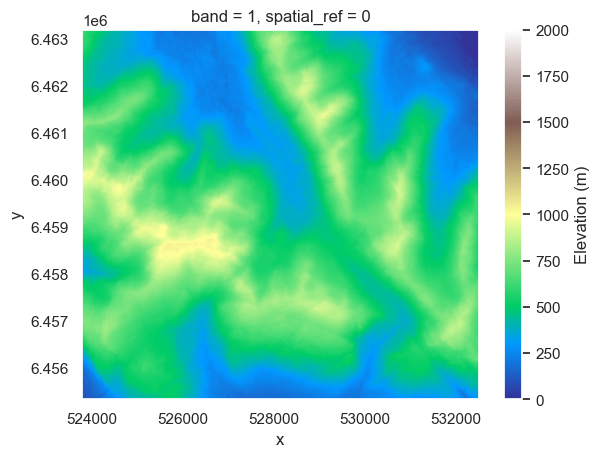

In [7]:
dem.squeeze().plot(cmap='terrain', vmin=0, vmax=2000, cbar_kwargs={'label': 'Elevation (m)'})

## Fill Missing Data 
#### Starting with Methods 1: Interpolation with `scipy.ndimage` which is good for small holes or edges with nans 

In [ ]:
# # Load your DEM
# dem_fill = rxr.open_rasterio("your_dem.tif", masked=True).squeeze()
dem_fill = dem.squeeze()

# Check for missing data
nodata_mask = np.isnan(dem_fill)

# Fill missing data with nearest neighbor
filled = dem_fill.copy()
filled.data[nodata_mask] = ndimage.generic_filter(
    dem_fill.data,
    function=lambda x: np.nanmean(x),
    size=5,  # 5x5 neighborhood
    mode='mirror'
)[nodata_mask]

# Replace DEM data
dem_fill.data = filled

# Save the filled DEM
dem_fill.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_ndimage.tif")

In [11]:
# check for missing data now that we filled everything... 
print("total pixels in the OG:", dem.sum().values)
print("# that are nan without filling:", dem.isnull().sum().values)
print("# that are nan with    filling:", dem_fill.isnull().sum().values)

total pixels in the OG: 9923080000.0
# that are nan without filling: 8695
# that are nan with    filling: 0


So, that worked out nicely. It did take 3 minutes... 

So perhaps in the future we would want another method? Below is an option commented out, and then below that, I will try a version with rasterio, then move on for now. 

Since the iterative fill is taking so long to run, let's try a faster option...

Commenting this block of code out for now, because I am not going to use it... let's see if we need it in the future 

In [ ]:
# def smart_fill_nans(data, max_iter=50):
#     filled = data.copy()
#     for _ in range(max_iter):
#         nan_mask = np.isnan(filled)
#         if not np.any(nan_mask):
#             break

#         # Get 4-neighbor average but only for NaNs
#         neighbors_sum = (
#             np.roll(filled, 1, axis=0) +
#             np.roll(filled, -1, axis=0) +
#             np.roll(filled, 1, axis=1) +
#             np.roll(filled, -1, axis=1)
#         )

#         neighbors_count = (
#             (~np.isnan(np.roll(filled, 1, axis=0))).astype(int) +
#             (~np.isnan(np.roll(filled, -1, axis=0))).astype(int) +
#             (~np.isnan(np.roll(filled, 1, axis=1))).astype(int) +
#             (~np.isnan(np.roll(filled, -1, axis=1))).astype(int)
#         )

#         avg_neighbors = neighbors_sum / np.where(neighbors_count == 0, np.nan, neighbors_count)

#         updated = filled.copy()
#         updated[nan_mask] = avg_neighbors[nan_mask]

#         # Only update those that changed
#         filled[nan_mask] = np.where(np.isnan(avg_neighbors[nan_mask]), filled[nan_mask], avg_neighbors[nan_mask])

#     return filled


# dem_array = dem_powderpatch_utm.data.squeeze()
# filled_array = smart_fill_nans(dem_array)

# # Replace DEM data and verify
# dem.data[:] = filled_array
# print("Remaining NaNs:", np.isnan(dem.data).sum())

Remaining NaNs: 286558


### Use GCAL's `FillNoData()` Utility for high-quality data filling for modeling

In [18]:
import subprocess

In [19]:
subprocess.run([
    "gdal_fillnodata.py",  # or "gdal_fillnodata"
    "-md", "5",            # max distance in pixels to search
    "-of", "GTiff",
    "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif",                  # input
    "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif"       # output
])

ERROR 1: /lib/x86_64-linux-gnu/libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /home/cassie/programs/miniforge3/envs/rasterio/lib/gdalplugins/../libgdal.so.36)
ERROR 1: /lib/x86_64-linux-gnu/libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /home/cassie/programs/miniforge3/envs/rasterio/lib/gdalplugins/../libgdal.so.36)
Traceback (most recent call last):
  File "/usr/bin/gdal_fillnodata.py", line 11, in <module>
    UseExceptions()
  File "/usr/lib/python3/dist-packages/osgeo/gdal.py", line 246, in UseExceptions
    from . import gdal_array
  File "/usr/lib/python3/dist-packages/osgeo/gdal_array.py", line 286, in <module>
    gdal.AllRegister()
  File "/usr/lib/python3/dist-packages/osgeo/gdal.py", line 5894, in AllRegister
    return _gdal.AllRegister(*args)
           ^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /lib/x86_64-linux-gnu/libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /home/cassie/programs/miniforge3/envs/rasterio/lib/gdalplugins/../libgdal

CompletedProcess(args=['gdal_fillnodata.py', '-md', '5', '-of', 'GTiff', '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif', '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif'], returncode=1)

That was giving an error... issues with GDAL loc. 

So, let's use GDAL via Python (not subprocess) 

In [ ]:
# COMMENTED OUT -  this code is good, but it alters the DEM in place

# # Register drivers
# gdal.UseExceptions()

# # Open your raster in update mode
# src_ds = gdal.Open("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif", gdal.GA_Update) # this alters the DEM in place
# band = src_ds.GetRasterBand(1)

# # Fill NoData holes
# gdal.FillNodata(targetBand=band, maskBand=None, maxSearchDist=5, smoothingIterations=0)

# # Save and close
# band = None
# src_ds = None

So instead, so the same thing with loading the dem and then saving the changes to a new one

In [26]:
# Paths
src_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif"
dst_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif"

# Copy the original raster to the new path
shutil.copy(src_path, dst_path)

# Open the copy in update mode
ds = gdal.Open(dst_path, gdal.GA_Update)
band = ds.GetRasterBand(1)

# Perform nodata filling
gdal.FillNodata(targetBand=band, maskBand=None, maxSearchDist=5, smoothingIterations=0)

# Clean up
band = None
ds = None

print(f"Filled raster saved to: {dst_path}")

Filled raster saved to: /hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif


In [28]:
# open the DEM to check, 
dst_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif"
gdal_dem = rioxarray.open_rasterio(dst_path, masked=True)
# gdal_dem

In [29]:
# check the dem for missing data
print("total pixels:", gdal_dem.sum().values)
print("# that are nan:", gdal_dem.isnull().sum().values)

total pixels: 9926209000.0
# that are nan: 0


## GDAL worked great. 
We can use this code to proceed with testing Wind Ninja and can use the same process in the future for DEM processing. 

### Now, we can resample the filled DEM

In [30]:
# Resample to 10m resolution
dem_10m = gdal_dem.rio.reproject(
    gdal_dem.rio.crs,
    shape=(
        int(gdal_dem.rio.height * 2 / 10),  # new height
        int(gdal_dem.rio.width * 2 / 10)    # new width
    ),
    resampling=rasterio.enums.Resampling.bilinear  # or average, cubic (using bilinear (or cublic) for elevation data is better compared to nearest)
)

dem_10m.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_10m_UTM_clip_powderpatch_filled_gdal.tif")

In [31]:
# Resample to 50m resolution
dem_50m = gdal_dem.rio.reproject(
    gdal_dem.rio.crs,
    shape=(
        int(gdal_dem.rio.height * 2 / 50),  # new height
        int(gdal_dem.rio.width * 2 / 50)    # new width
    ),
    resampling=rasterio.enums.Resampling.bilinear  # or average, cubic
)

dem_50m.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_50m_UTM_clip_powderpatch_filled_gdal.tif")

In [34]:
# Resample to 50m resolution
dem_100m = gdal_dem.rio.reproject(
    gdal_dem.rio.crs,
    shape=(
        int(gdal_dem.rio.height * 2 / 100),  # new height
        int(gdal_dem.rio.width * 2 / 100)    # new width
    ),
    resampling=rasterio.enums.Resampling.bilinear  # or average, cubic
)

dem_100m.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_100m_UTM_clip_powderpatch_filled_gdal.tif")

In [35]:
# check the dem for missing data
print("gdal # that are nan:", gdal_dem.isnull().sum().values)
print("10 m # that are nan:", dem_10m.isnull().sum().values)
print("50 m # that are nan:", dem_50m.isnull().sum().values)
print("100 m # that are nan:", dem_100m.isnull().sum().values)

gdal # that are nan: 0
10 m # that are nan: 0
50 m # that are nan: 0
100 m # that are nan: 0


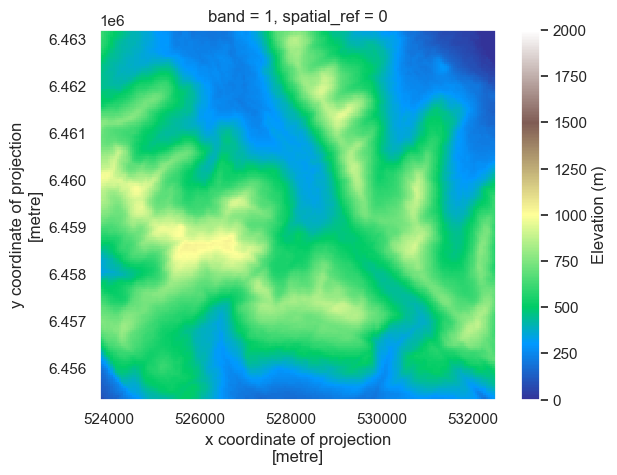

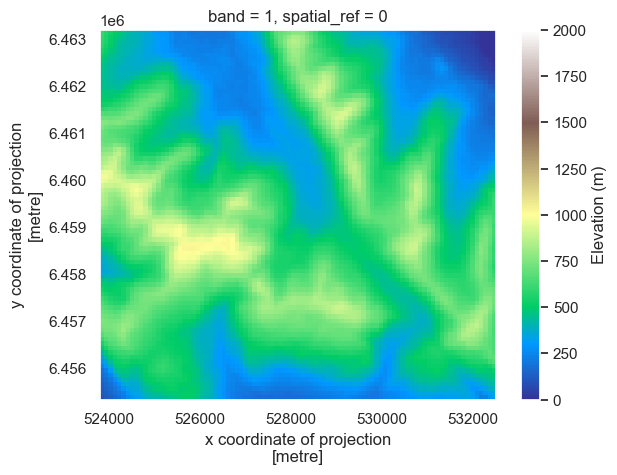

In [37]:
dem_50m.squeeze().plot(cmap='terrain', vmin=0, vmax=2000, cbar_kwargs={'label': 'Elevation (m)'})
plt.show()
dem_100m.squeeze().plot(cmap='terrain', vmin=0, vmax=2000, cbar_kwargs={'label': 'Elevation (m)'})

Okay, we are finished with the DEM filling and resampling. Let's move on to the wind data. 


When I have time later, I should move this DEM work into it's own script so that I can have all the code to work with DEMs in one place in the future

## Now, the wind data

We just want to save a week or a month of a wind speed and wind direction for the clipped area defined above to test...

In [304]:
filepath = "/hdd/snow_hydrology/hrrrak/netcdf/"
filename = "hrrrak_merged_grib_f567_WY2025_test1.nc"

# load data
ds_hrrr = xr.open_dataset(filepath + filename)
# ds_hrrr = ds_hrrr.rio.write_crs('EPSG:32608', inplace=True)  # EPSG:32608 is the UTM zone 8N, which is the zone for the Powderpatch area
ds_hrrr = ds_hrrr.rio.write_crs('EPSG:4326', inplace=True)  # the data is in lat/lon
ds_hrrr

<xarray.Dataset> Size: 413MB
Dimensions:                  (time: 4722, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 38kB 2024-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 38kB ...
    valid_time               (time) datetime64[ns] 38kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Dimensions without coordinates: y, x
Data variables: (12/52)
    pt                       (time, y, x) float32 8MB ...
    temp                     (time, y, x) float32 8MB ...
    d2m                      (time, y, x) float32 8MB ...
    sh2                      (time, y, x) float32 8MB ...
    rh                       (time, y, x) float32 8MB ...
    u10                      (time, y, x) float32 8MB ...
    ...                       ...
    lai                      (time, y, x) float32 8MB ...
    vgtyp                    (time, y, x) float32 8MB ...
    cloud_total              (time, y, x) float32 8MB ...
    cloud_high               (time, y, x) float32 8MB ...
    cloud_low                (time, y, x) float32 8MB ...
    wind                     (time, y, x) float32 8MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

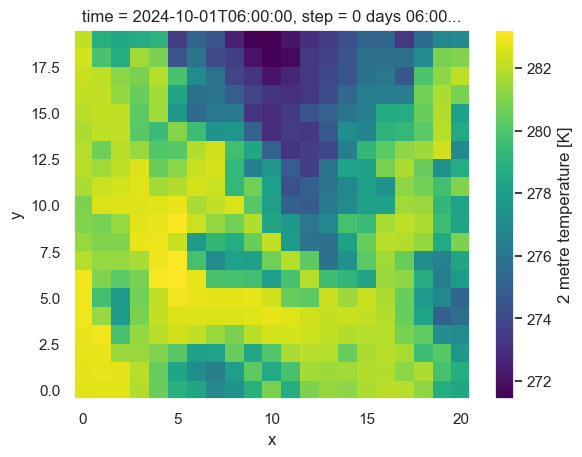

In [305]:
ds_hrrr["temp"][1].plot()

<xarray.Dataset> Size: 32MB
Dimensions:                  (time: 4722, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 38kB 2024-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 38kB ...
    valid_time               (time) datetime64[ns] 38kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Dimensions without coordinates: y, x
Data variables:
    u10                      (time, y, x) float32 8MB -4.269 -2.144 ... 0.7717
    v10                      (time, y, x) float32 8MB -3.529 -3.779 ... 1.997
    wind_speed               (time, y, x) float32 8MB 5.539 4.345 ... 2.141
    wind_direction           (time, y, x) float32 8MB -129.6 -150.4 ... 21.13
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

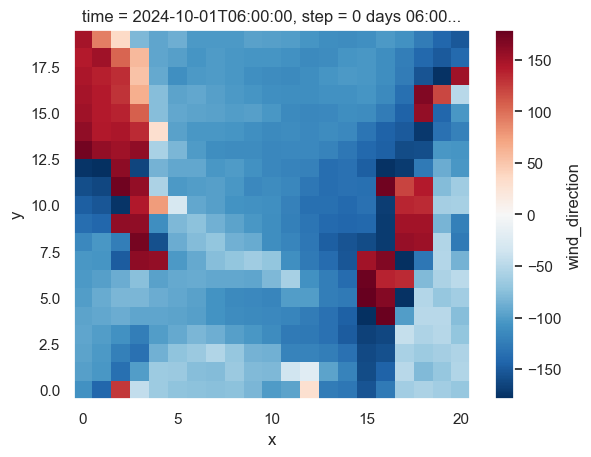

In [306]:
# Now we know we have the wind speed, calculated from u and v components, in the ds_hrrr dataset.
# And we want to calculate the wind direction from the u and v components.
# The wind direction is calculated as the arctangent of the ratio of the u and v
# components, using the numpy arctan2 function.
# The wind direction is given in degrees, with 0 degrees being north, 90 degrees
# being east, 180 degrees being south, and 270 degrees being west.

# u10 = west-east wind component (m/s)
# v10 = south-north wind component (m/s)

# the general equation being, 
# wind_dir = (180 / np.pi) * np.arctan2(-u10, -v10)
# wind_dir = (wind_dir + 360) % 360  # Convert to compass bearing

# calculate wind speed from u and v components
ds_hrrr['wind_speed'] = np.sqrt(ds_hrrr['u10']**2 + ds_hrrr['v10']**2)

# implemented, 
ds_hrrr["wind_direction"] = (180 * np.arctan2(ds_hrrr["u10"], ds_hrrr["v10"]) / np.pi)
ds_hrrr["wind_direction"][1].plot()

# Now we want to save a very simple version of a dataset, with only the wind speed and direction, for use in WindNinja.
# ds_hrrr_wind = ds_hrrr[["wind_speed", "wind_direction"]].copy()
ds_hrrr_wind = ds_hrrr[["u10", "v10", "wind_speed", "wind_direction"]].copy()
ds_hrrr_wind

A result of 
* 0° means wind is from the north
* 90° = from the east
* 180° = from the south
* 270° = from the west

`ds.x` and `ds.y` are 2D arrays, and `rioxarray` expects `x` and `y` to be 1D coordinates -- eg., x (x,) and y(y,)

So one solution is to concert `x` and `y` to 1D coordinates

# I, finally, got this sorted omg

In [ ]:
ds = ds_hrrr_wind.copy(deep=True) 

# Step 1: Rename dimensions if needed and set spatial dims
ds = ds.rename({'longitude': 'x', 'latitude': 'y'})
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')

# Step 2: Extract 1D x and y coordinates from the 2D grid
# This assumes the grid is rectilinear — typical for HRRR data

# Grab 1D x and y
x_1d = ds['x'].isel(y=0)  # same x values across rows
y_1d = ds['y'].isel(x=0)  # same y values down columns

# Assign 1D coords to the dataset
ds = ds.assign_coords(x=x_1d, y=y_1d)

# Step 3: Drop the 2D coords from the coordinate system
ds = ds.drop_vars(['x', 'y'])  # remove old 2D variables
ds = ds.set_coords([])         # ensure no unexpected spatial coords

# Step 4: Reassign the cleaned 1D coords
ds = ds.assign_coords({'x': x_1d, 'y': y_1d})

# Step 5: Write CRS (NO, reproject to UTM)
# ds = ds.rio.write_crs("EPSG:32608")
# Now reproject to UTM
ds_utm = ds.rio.reproject("EPSG:32608")

In [300]:
print(ds.x.dims)  # should be ('x',)
print(ds.y.dims)  # should be ('y',)

('x',)
('y',)


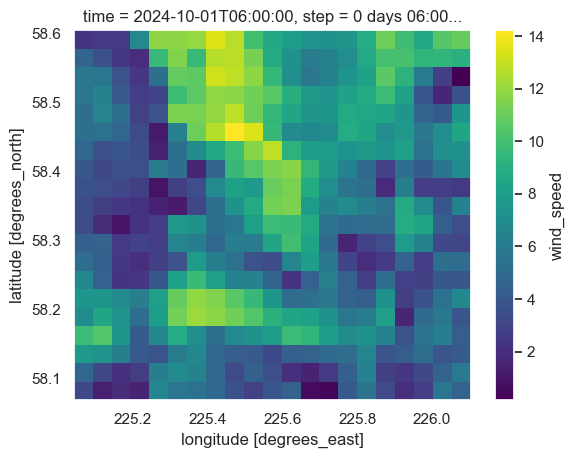

In [301]:
ds['wind_speed'][1].plot()

In [316]:
# Transformer from WGS84 (lat/lon) to UTM Zone 8N
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)

# Input in (lon, lat) order for Powderpatch area
xmin_lon, ymin_lat = -134.594876, 58.238519
xmax_lon, ymax_lat = -134.445151, 58.308517

# Convert all corners
xmin, ymin = transformer.transform(xmin_lon, ymin_lat)
xmax, ymax = transformer.transform(xmax_lon, ymax_lat)

print(f"UTM BBox: xmin={xmin:.2f}, xmax={xmax:.2f}, ymin={ymin:.2f}, ymax={ymax:.2f}")

UTM BBox: xmin=523787.03, xmax=532513.90, ymin=6455337.22, ymax=6463193.11


In [317]:
# check the crs of the xarray dataset
print('crs of the gdal tif', gdal_dem.rio.crs)
print("crs of the xarray dataset:", ds_hrrr.rio.crs)
print("crs of the xarray dataset:", ds_hrrr_wind.rio.crs)
print("crs of the xarray dataset:", ds_utm.rio.crs)

crs of the gdal tif EPSG:32608
crs of the xarray dataset: EPSG:4326
crs of the xarray dataset: EPSG:4326
crs of the xarray dataset: EPSG:32608


In [231]:
# # Bounding box in lat/lon
# xmin, ymin, xmax, ymax = 225.3, 58.238519, 225.8, 58.308517

# clipped = ds_hrrr_wind.rio.clip_box(minx=xmin, maxx=xmax, miny=ymin, maxy=ymax)

In [ ]:
# Clip all variables spatially
ds_utm_clipped = ds_utm.rio.clip_box(minx=xmin, miny=ymin, maxx=xmax, maxy=ymax)

# ds_hrrr_wind_clipped = ds_utm.rio.clip_box(minx=523787.03, miny=6455337.22, 
                                                #  maxx=532513.90, maxy=6463193.11)

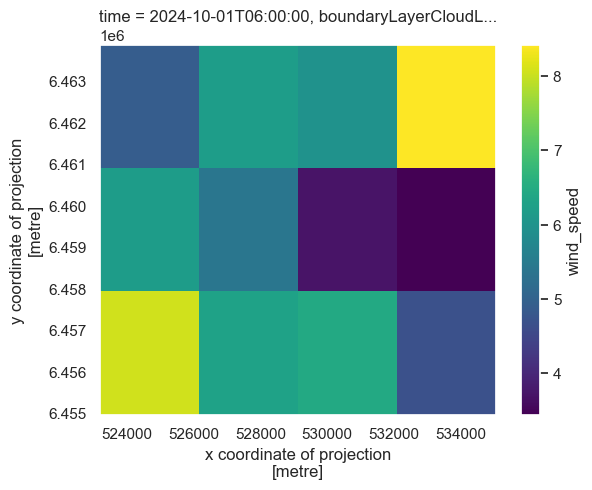

In [320]:
ds_utm_clipped['wind_speed'][1].plot()

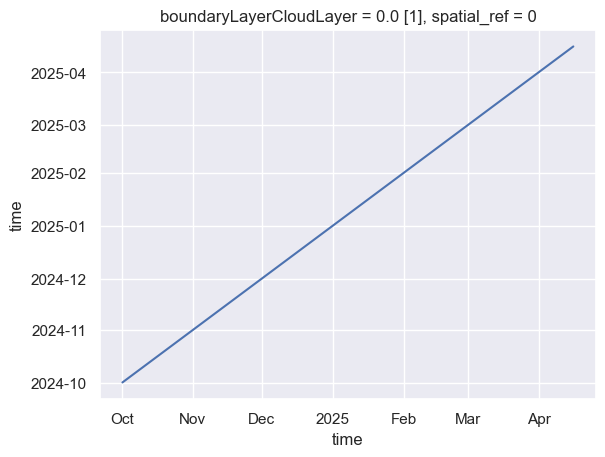

In [322]:
ds_utm_clipped['time'].plot()

In [321]:
ds_utm_clipped.to_netcdf("/hdd/snow_hydrology/hrrrak/netcdf/ds_hrrr_wind_powderpatch_test1_UTM.nc")

In [323]:
# We want to create a short time series of wind speed and direction for the Powder Patch area.
# We can use the `sel` method to select a specific time range.
# For example, we can select the first 10 time steps.
ds_utm_clipped_short = ds_utm_clipped.sel(time=slice("2024-10-01", "2024-12-01"))
ds_utm_clipped_short

<xarray.Dataset> Size: 319kB
Dimensions:                  (x: 4, y: 3, time: 1478)
Coordinates:
  * x                        (x) float64 32B 5.247e+05 5.276e+05 ... 5.336e+05
  * y                        (y) float64 24B 6.462e+06 6.459e+06 6.456e+06
  * time                     (time) datetime64[ns] 12kB 2024-10-01T05:00:00 ....
    boundaryLayerCloudLayer  float64 8B 0.0
    valid_time               (time) datetime64[ns] 12kB 2024-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 12kB 05:00:00 ... 05:00:00
    spatial_ref              int64 8B 0
Data variables:
    u10                      (time, y, x) float32 71kB -5.456 -6.269 ... -5.035
    v10                      (time, y, x) float32 71kB 1.158 -0.5916 ... 0.02843
    wind_speed               (time, y, x) float32 71kB 5.578 6.297 ... 5.035
    wind_direction           (time, y, x) float32 71kB -78.01 -95.39 ... -89.68
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

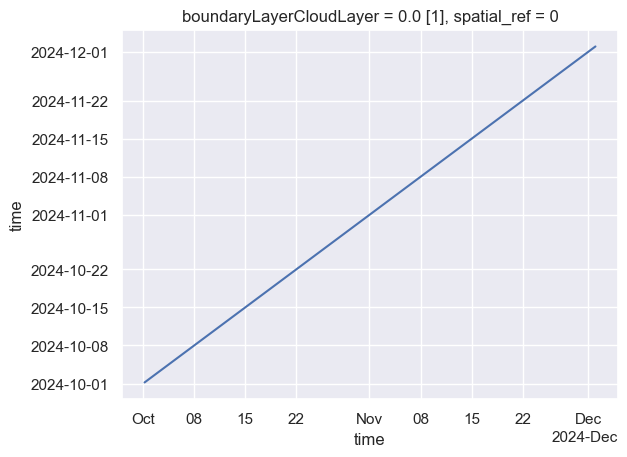

In [324]:
ds_utm_clipped_short['time'].plot()

In [325]:
# Save the short time series of wind speed and direction to a NetCDF file
ds_utm_clipped_short.to_netcdf("/hdd/snow_hydrology/hrrrak/netcdf/ds_hrrr_wind_powderpatch_test1_UTM_short_time.nc")

## Wind Ninja needs the wind speed and direction in ascii files 

In [ ]:
# # now we need to save the wind speed and direction in ascii files for WindNinja
# ds_utm_clipped_short['wind_speed'].to_dataframe().to_csv("/hdd/snow_hydrology/wind_ninja/test/ds_hrrr_wind_powderpatch_test1_UTM_short_time_wind_speed.csv")
# ds_utm_clipped_short['wind_direction'].to_dataframe().to_csv("/hdd/snow_hydrology/wind_ninja/test/ds_hrrr_wind_powderpatch_test1_UTM_short_time_wind_direction.csv")

# Open Example Input Files

The example files are 

4km by 4km domain around Davos at 100 m resolution for input, 10 m for output 

Units, 
* elevation in meters
* wind speed in m/s and, 
* wind direction in degrees

In [339]:
# open the example input files 
example_wind_speed = "/hdd/snow_hydrology/wind_ninja/example_files/wnss.asc"

with open(example_wind_speed, 'r') as f:
    asc_content = f.readlines()

In [340]:
asc_content

['ncols\t  40\n',
 'nrows\t  40\n',
 'xllcorner\t2782000\n',
 'yllcorner\t1182000\n',
 'cellsize\t 100\n',
 'NODATA_value\t-9999\n',
 '0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.8\t0.8\t0.8\t0.8\t0.9\t0.9\t0.9\t0.9\t0.9\t1\t1.2\t1.3\t1.5\t1.5\t1.5\t1.6\t1.6\t1.7\t1.8\t1.9\t1.9\t1.9\n',
 '0.6\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.6\t0.6\t0.6\t0.6\t0.6\t0.6\t0.6\t0.7\t0.7\t0.7\t0.7\t0.8\t0.8\t0.8\t0.9\t1\t1.1\t1.2\t1.3\t1.3\t1.4\t1.5\t1.6\t1.6\t1.7\t1.8\t1.9\t2\t2\n',
 '0.6\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.6\t0.6\t0.5\t0.5\t0.5\t0.5\t0.5\t0.5\t0.5\t0.6\t0.6\t0.6\t0.7\t0.7\t0.8\t0.8\t0.8\t0.9\t1\t1.1\t1.2\t1.2\t1.2\t1.3\t1.4\t1.4\t1.5\t1.6\t1.7\t1.8\t1.8\n',
 '0.6\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.6\t0.6\t0.6\t0.5\t0.5\t0.5\t0.4\t0.4\t0.5\t0.5\t0.5\t0.6\t0.6\t0.7\t0.7\t0.7\t0.7\t0.8\t0.9\t0.9\t1\t1.1\t1.1\t1.1\t1.2\t1.2\t1.2\t1.3\t1.5\t1.5\t1.6\t1.7\n',
 '0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.6\t0.6\t0.6\t0.

In [ ]:
example_wind_direction = "/hdd/snow_hydrology/wind_ninja/example_files/wnds.asc"

with open(example_wind_direction, 'r') as f:
    asc_content = f.readlines()

In [337]:
asc_content

['ncols\t  40\n',
 'nrows\t  40\n',
 'xllcorner\t2782000\n',
 'yllcorner\t1182000\n',
 'cellsize\t 100\n',
 'NODATA_value\t-9999\n',
 '0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.8\t0.8\t0.8\t0.8\t0.9\t0.9\t0.9\t0.9\t0.9\t1\t1.2\t1.3\t1.5\t1.5\t1.5\t1.6\t1.6\t1.7\t1.8\t1.9\t1.9\t1.9\n',
 '0.6\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.6\t0.6\t0.6\t0.6\t0.6\t0.6\t0.6\t0.7\t0.7\t0.7\t0.7\t0.8\t0.8\t0.8\t0.9\t1\t1.1\t1.2\t1.3\t1.3\t1.4\t1.5\t1.6\t1.6\t1.7\t1.8\t1.9\t2\t2\n',
 '0.6\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.6\t0.6\t0.5\t0.5\t0.5\t0.5\t0.5\t0.5\t0.5\t0.6\t0.6\t0.6\t0.7\t0.7\t0.8\t0.8\t0.8\t0.9\t1\t1.1\t1.2\t1.2\t1.2\t1.3\t1.4\t1.4\t1.5\t1.6\t1.7\t1.8\t1.8\n',
 '0.6\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.6\t0.6\t0.6\t0.5\t0.5\t0.5\t0.4\t0.4\t0.5\t0.5\t0.5\t0.6\t0.6\t0.7\t0.7\t0.7\t0.7\t0.8\t0.9\t0.9\t1\t1.1\t1.1\t1.1\t1.2\t1.2\t1.2\t1.3\t1.5\t1.5\t1.6\t1.7\n',
 '0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.7\t0.6\t0.6\t0.6\t0.

### These files are wind speed and wind direction at a given timestep (one hour)...

So hte Ascii File Format is, 

ncols         40 (4km x 4km at 100 m res, gives 40)\
nrows         40\
xllcorner     2782000\
yllcorner     1182000\
cellsize      100\
NODATA_value  -9999\
data row 1\
data row 2\
...\
data row N



In [ ]:
def write_ascii_grid(filename, data, xllcorner, yllcorner, cellsize, nodata_value=-9999):
    """
    Write a 2D numpy array to ESRI ASCII format (.asc)
    
    Parameters:
    - filename: output file path
    - data: 2D numpy array
    - xllcorner, yllcorner: lower-left corner coordinates (meters)
    - cellsize: resolution (assumed square)
    - nodata_value: value to use for missing data
    """
    nrows, ncols = data.shape

    # Flip data vertically: ASCII grid is top-down
    data_flipped = np.flipud(data)

    with open(filename, 'w') as f:
        f.write(f"ncols         {ncols}\n")
        f.write(f"nrows         {nrows}\n")
        f.write(f"xllcorner     {xllcorner}\n")
        f.write(f"yllcorner     {yllcorner}\n")
        f.write(f"cellsize      {cellsize}\n")
        f.write(f"NODATA_value  {nodata_value}\n")
        
        for row in data_flipped:
            row_str = '\t'.join([f"{val:.2f}" if np.isfinite(val) else str(nodata_value) for val in row])
            f.write(row_str + '\n')

In [ ]:
# get ds_utm['wind_speed'] and ds_utm['wind_direction'] as 2D numpy arrays
wind_speed = ds_utm['wind_speed'].values
wind_dir = ds_utm['wind_direction'].values

In [ ]:
# Assume wind_speed and wind_dir are 2D numpy arrays
# Get grid metadata from your dataset (ds_utm)

cellsize = ds_utm.x.diff("x").mean().item()  # Assumes uniform spacing
xll = ds_utm.x.min().item()
yll = ds_utm.y.min().item()

write_ascii_grid("/hdd/snow_hydrology/wind_ninja/test/wind_speed_test.asc", wind_speed, xll, yll, cellsize)
write_ascii_grid("/hdd/snow_hydrology/wind_ninja/test/wind_dir_test.asc", wind_dir, xll, yll, cellsize)


## BUT the wnss and wnds files are at a given time step (one hour) 

In [359]:
def write_ascii_grid(filename, data, xllcorner, yllcorner, cellsize, nodata_val=-9999):
    nrows, ncols = data.shape
    with open(filename, 'w') as f:
        f.write(f"ncols         {ncols}\n")
        f.write(f"nrows         {nrows}\n")
        f.write(f"xllcorner     {xllcorner}\n")
        f.write(f"yllcorner     {yllcorner}\n")
        f.write(f"cellsize      {cellsize}\n")
        f.write(f"NODATA_value  {nodata_val}\n")
        for row in data:
            f.write("\t".join([f"{val:.1f}" if not np.isnan(val) else str(nodata_val) for val in row]))
            f.write("\n")

Then loop through time steps and write to file, 

In [361]:
# Get cellsize and lower-left corner
cellsize = float(ds_utm_clipped_short.x.diff("x").mean())
xll = float(ds_utm_clipped_short.x.min())
yll = float(ds_utm_clipped_short.y.min())

# Loop through time steps
for i in range(ds_utm_clipped_short.dims["time"]):
    wind_speed_2d = ds_utm_clipped_short['wind_speed'].isel(time=i).values
    wind_dir_2d = ds_utm_clipped_short['wind_direction'].isel(time=i).values

    # Replace NaNs if needed
    wind_speed_2d = np.nan_to_num(wind_speed_2d, nan=-9999)
    wind_dir_2d = np.nan_to_num(wind_dir_2d, nan=-9999)

    # Write to file with padded index
    write_ascii_grid(f"/hdd/snow_hydrology/wind_ninja/test/wind_speed_{i:04d}.asc", wind_speed_2d, xll, yll, cellsize)
    write_ascii_grid(f"/hdd/snow_hydrology/wind_ninja/test/wind_dir_{i:04d}.asc", wind_dir_2d, xll, yll, cellsize)


/tmp/ipykernel_3992095/2065539972.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds_utm_clipped_short.dims["time"]):


Loop with the timestamp in the name, 

In [ ]:
for i in range(ds_utm.dims["time"]):
    # Extract timestamp as a string, e.g., '2025-07-30T00-00'
    timestamp = str(ds_utm.time[i].values)
    timestamp_clean = timestamp.replace(":", "-").replace("T", "_").split(".")[0]

    wind_speed_2d = ds_utm['wind_speed'].isel(time=i).values
    wind_dir_2d = ds_utm['wind_direction'].isel(time=i).values

    # Replace NaNs
    wind_speed_2d = np.nan_to_num(wind_speed_2d, nan=-9999)
    wind_dir_2d = np.nan_to_num(wind_dir_2d, nan=-9999)

    # Write to files with timestamp in the filename
    write_ascii_grid(f"/hdd/snow_hydrology/wind_ninja/test/wind_speed_{timestamp_clean}.asc", wind_speed_2d, xll, yll, cellsize)
    write_ascii_grid(f"/hdd/snow_hydrology/wind_ninja/test/wind_dir_{timestamp_clean}.asc", wind_dir_2d, xll, yll, cellsize)

In [ ]:
# now open 1 example file and see if the file structure looks right 
example_wind_speed = "/hdd/snow_hydrology/wind_ninja/test/wind_speed_0000.asc"
with open(example_wind_speed, 'r') as f:
    asc_content = f.readlines()

In [363]:
asc_content

['ncols         4\n',
 'nrows         3\n',
 'xllcorner     524669.000980743\n',
 'yllcorner     6456453.557460933\n',
 'cellsize      2969.4091761768796\n',
 'NODATA_value  -9999\n',
 '5.6\t6.3\t5.8\t9.7\n',
 '7.7\t5.5\t3.8\t3.4\n',
 '9.7\t7.2\t7.6\t5.8\n']

In [365]:
import zipfile
import os

### Full script including zipping files, 

In [ ]:
# --- function to write an ASCII grid ---
def write_ascii_grid(filename, array, xllcorner, yllcorner, cellsize, nodata_value=-9999):
    nrows, ncols = array.shape
    with open(filename, 'w') as f:
        f.write(f"ncols\t{ncols}\n")
        f.write(f"nrows\t{nrows}\n")
        f.write(f"xllcorner\t{xllcorner}\n")
        f.write(f"yllcorner\t{yllcorner}\n")
        f.write(f"cellsize\t{cellsize}\n")
        f.write(f"NODATA_value\t{nodata_value}\n")
        for row in array:
            row_str = '\t'.join(f"{val:.2f}" if val != nodata_value else f"{int(nodata_value)}" for val in row)
            f.write(row_str + '\n')

# --- write all timesteps to .asc files ---
asc_files = []

for i in range(ds_utm.dims["time"]):
    timestamp = str(ds_utm.time[i].values)
    timestamp_clean = timestamp.replace(":", "-").replace("T", "_").split(".")[0]

    wind_speed_2d = ds_utm['wind_speed'].isel(time=i).values
    wind_dir_2d = ds_utm['wind_direction'].isel(time=i).values

    wind_speed_2d = np.nan_to_num(wind_speed_2d, nan=-9999)
    wind_dir_2d = np.nan_to_num(wind_dir_2d, nan=-9999)

    fname_speed = f"/hdd/snow_hydrology/wind_ninja/test/wind_speed_{timestamp_clean}.asc"
    fname_dir = f"/hdd/snow_hydrology/wind_ninja/test/wind_dir_{timestamp_clean}.asc"

    write_ascii_grid(fname_speed, wind_speed_2d, xll, yll, cellsize)
    write_ascii_grid(fname_dir, wind_dir_2d, xll, yll, cellsize)

    asc_files.extend([fname_speed, fname_dir])

# --- zip the results ---
zip_filename = "/hdd/snow_hydrology/wind_ninja/test/wind_ascii_files.zip"
with zipfile.ZipFile(zip_filename, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file in asc_files:
        zipf.write(file)
        os.remove(file)  # optional: remove original after adding to zip

print(f"Zipped {len(asc_files)} files to {zip_filename}")